In [237]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.pipeline import Pipeline  # Use the imblearn pipeline
from xgboost import XGBRegressor as xgb
from sklearn.utils.validation import column_or_1d
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [140]:
%run ./ml_model_init.ipynb

## Functions


In [11]:
# For the linear model
def Linear_regression(features_train, features_pred, target_train):
    # bool_cols = features_train.drop(columns=['was_home']).columns.tolist()

    bool_cols = features_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_cols = features_train.select_dtypes(include=['object', 'category']).columns.tolist()

    print('================>', bool_cols, categorical_cols)
    numerical_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('one_hot_encoder', OneHotEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, bool_cols),
            ('cat', categorical_transformer, categorical_cols),
        ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ])

    model = TransformedTargetRegressor(regressor=pipeline, transformer=StandardScaler())
    model.fit(features_train, target_train)

    return model.predict(features_pred)

# Decision Tree Model
def DecisionTreeRegression(features_train, features_pred, target_train):
    bool_cols = features_train.drop(columns=['was_home']).columns.tolist()
    categorical_cols = ['was_home']

    numerical_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('one_hot_encoder', OneHotEncoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, bool_cols),
            ('cat', categorical_transformer, categorical_cols),
        ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeRegressor())
    ])

    model = TransformedTargetRegressor(regressor=pipeline, transformer=StandardScaler())
    model.fit(features_train, target_train)

    return model.predict(features_pred)

# RandomForestRegressor
def RandomForestRegression(features_train, features_pred, target_train, hyperparameters):
    model = TransformedTargetRegressor(RandomForestRegressor(
        n_estimators=hyperparameters['n_estimators'],  max_depth=hyperparameters['max_depth'], criterion=hyperparameters['criterion'], random_state=18), transformer=StandardScaler())
    model.fit(features_train, target_train)

    pred_pred = model.predict(features_pred)

def XGBoostRegression(features_train, features_pred, target_train, hyperparameters):
    regressor = xgb(learning_rate=hyperparameters["learning_rate"],
                    n_estimators=hyperparameters["n_estimators"],
                    max_depth=hyperparameters["max_depth"],
                    eval_metric='rmsle')

    model = TransformedTargetRegressor(regressor, transformer=StandardScaler())


    model.fit(features_train, target_train)

    return model.predict(features_pred)


def Random_Forest_Classifier(features_train, features_pred, target_train, hy_params):
    encoder = LabelEncoder()
    cs_train_ = encoder.fit_transform(target_train)

    # bool_cols = features_train.drop(columns=['was_home']).columns.tolist()
    # categorical_cols = ['was_home']
    bool_cols = features_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
    categorical_cols = features_train.select_dtypes(include=['object', 'category']).columns.tolist()

    numerical_transformer = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ('one_hot_encoder', OneHotEncoder(sparse_output=False)),
        # ('to_dense', ToDense())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, bool_cols),
            ('cat', categorical_transformer, categorical_cols),
        ])

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', BorderlineSMOTE(sampling_strategy='auto', random_state=42)),  # Apply SMOTE to the data
        ('classifier', RandomForestClassifier(bootstrap = hy_params['bootstrap'], min_samples_split = hy_params['min_samples_split'], n_estimators =hy_params['n_estimators']  , class_weight='balanced', random_state=42))  # Random Forest Classifier
    ])

    pipeline.fit(features_train, cs_train_)

    # Make predictions
    return pipeline.predict(features_pred)

In [12]:
data_tar_preds = data_tar_.copy()

## Goals Predictor


In [ ]:

xg_data= data[(data['minutes_5'] >= 300) & (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                     'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home', 'goals_scored',
                                                                     'goals_scored_3','goals_scored_5','xG_3',  'xG_5', 'expected_goals_5', 'expected_goals_conceded_3',
                                                                     'expected_goals_conceded_5', 'whh', 'whd', 'wha']]

xg_data_tar = data_tar[(data_tar['minutes_5'] >= 300) & (data_tar['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                     'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home', 'goals_scored',
                                                                     'goals_scored_3','goals_scored_5','xG_3',  'xG_5', 'expected_goals_5', 'expected_goals_conceded_3',
                                                                     'expected_goals_conceded_5', 'whh', 'whd', 'wha']]

In [229]:
xg_data = xg_data.dropna()
xg = xg_data[['goals_scored',]]
xg_feats = xg_data.drop('goals_scored', axis=1)

xg_tar = xg_data_tar[['goals_scored',]]
xg_feats_tar = xg_data_tar.drop('goals_scored', axis=1)

xg_tar.shape

(129, 1)

In [238]:
# position = xg_feats['position']
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OHE.fit(xg_feats[['position', 'was_home']])

xg_encoded = OHE.transform(xg_feats[['position', 'was_home']])
xg_encoded_tar = OHE.transform(xg_feats_tar[['position', 'was_home']])

xg_one_hot_df = pd.DataFrame(xg_encoded,  columns=OHE.get_feature_names_out(['position', 'was_home']))
xg_one_hot_df_tar = pd.DataFrame(xg_encoded_tar,  columns=OHE.get_feature_names_out(['position', 'was_home']))

xg_feats_ = xg_feats.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)
xg_feats_tar_ = xg_feats_tar.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)

xg_feats_sklearn_encoded = pd.concat([xg_feats_, xg_one_hot_df], axis=1)
xg_feats_sklearn_encoded_tar = pd.concat([xg_feats_tar_, xg_one_hot_df_tar], axis=1)
print(xg_feats_sklearn_encoded_tar.shape)

xg_scaler = MinMaxScaler()

xg_scaler.fit(xg_feats_sklearn_encoded)

xg_scaled = xg_scaler.transform(xg_feats_sklearn_encoded)
xg_scaled_tar = xg_scaler.transform(xg_feats_sklearn_encoded_tar)

xg_feats_sklearn_enc_scaled = pd.DataFrame(xg_scaled, columns=[xg_feats_sklearn_encoded.columns])
xg_feats_sklearn_enc_scaled_tar = pd.DataFrame(xg_scaled_tar, columns=[xg_feats_sklearn_encoded_tar.columns])

(129, 27)


In [239]:
# xg_feats = feats[feats['position'].notnull()]
xg_feats_train, xg_feats_test, xg_train, xg_test = train_test_split(xg_feats_sklearn_enc_scaled, xg , test_size=0.2, random_state=42)


In [240]:
xg_data['goals_scored_3'].min()

0.0

In [241]:
xg_feats_train[['goals_scored_3', 'goals_scored_5']]

,goals_scored_3,goals_scored_5
1866,0.000,0.0
3101,0.125,0.1
10981,0.000,0.0
2122,0.000,0.0
8935,0.000,0.0
...,...,...
5734,0.000,0.0
5191,0.500,0.4
5390,0.000,0.0
860,0.125,0.1


In [249]:
param_grid = {
    'subsample': 0.8,
    'reg_lambda': 10,
    'reg_alpha': 0.01,
    'n_estimators': 200,
    'min_child_weight': 5,
    'max_depth': 3,
    'learning_rate': 0.05,
    'gamma': 0.1,
    'colsample_bytree': 0.8
}

# Define XGBoost model
xg_model = xg_model = xgb(objective="reg:squarederror", eval_metric="rmse", **param_grid)

# Train model
xg_model.fit(xg_feats_train, xg_train)

# Predict on test set
xg_pred_test = xg_model.predict(xg_feats_test)

# Evaluate performance
mae = mean_absolute_error(xg_test, xg_pred_test)
rmse = np.sqrt(mean_squared_error(xg_test, xg_pred_test))
r2 = r2_score(xg_test, xg_pred_test)

print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test R² Score: {r2}")

Test MAE: 0.20643110226811073
Test RMSE: 0.3570184107213761
Test R² Score: 0.07871651649475098


In [243]:
# Predict xG for current gameweek
xg_pred = xg_model.predict(xg_feats_sklearn_enc_scaled_tar)

In [248]:
xg_pred.min()

0.014967056

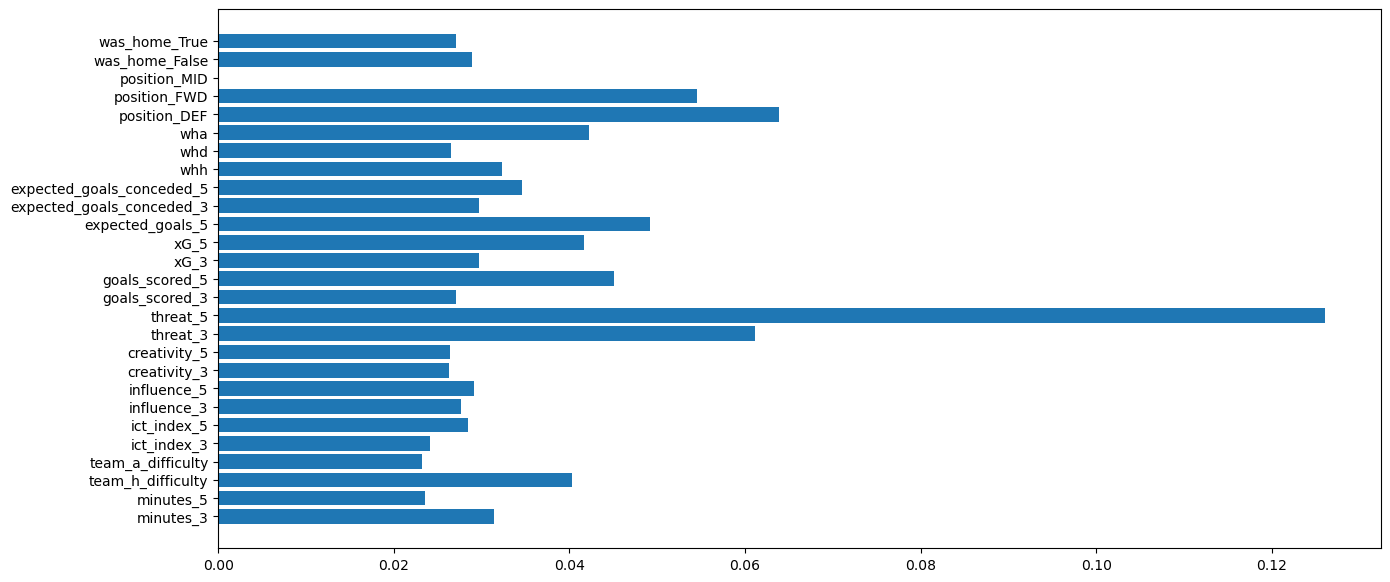

In [244]:

importances = xg_model.feature_importances_

# Plot
plt.figure(figsize=(15, 7))
plt.barh(xg_feats_sklearn_encoded.columns, importances)
plt.show()


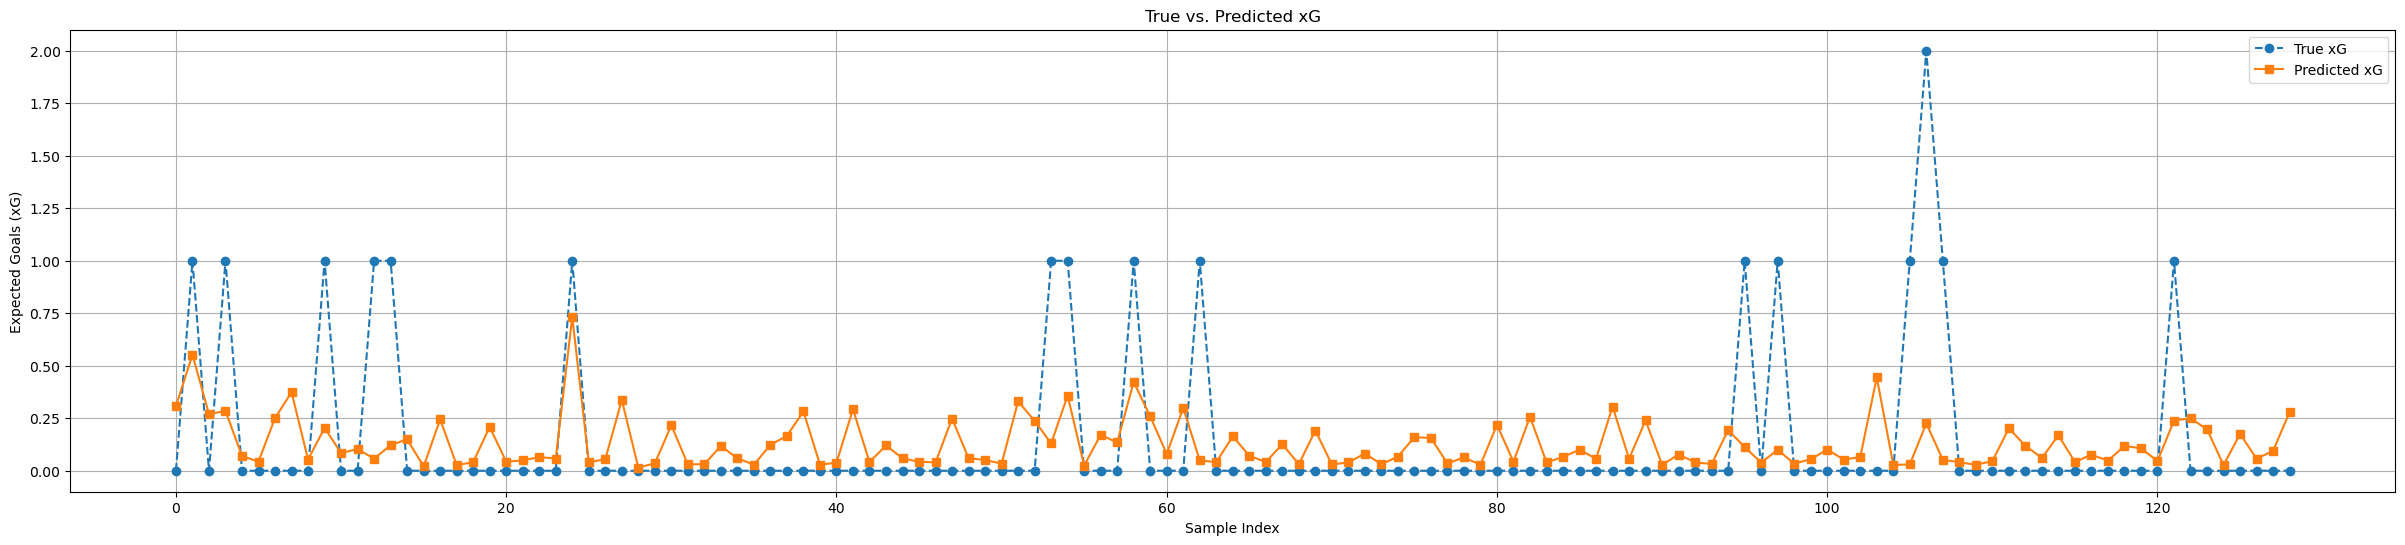

In [245]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(30, 6))
plt.plot(xg_tar.values, label="True xG", marker='o', linestyle='dashed')  # Convert DataFrame to array
plt.plot(xg_pred, label="Predicted xG", marker='s', linestyle='solid')

# Labels and Title
plt.xlabel("Sample Index")
plt.ylabel("Expected Goals (xG)")
plt.title("True vs. Predicted xG")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
xg_tar['xg_pred'] = xg_pred
# xg_tar = xg_tar.drop('xG', axis=1)
# comb_data = xg_data_tar.join(xg_tar)
# comb_data

def add_preds(row):
    if row.name in list(xg_tar.index):
        # print(row.name, xg_tar.loc[row.name, 'xg_pred'])
        row['xg_pred'] = xg_tar.loc[row.name, 'xg_pred']
    else:
        row['xg_pred'] = 0
    return row
data_tar_preds = data_tar_preds.apply(add_preds, axis=1)
data_tar_preds['xg_pred']

C:\Users\Ilyas\AppData\Local\Temp\ipykernel_22552\445589427.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  xg_tar['xg_pred'] = xg_pred


12      0.000000
19      0.000000
44      0.000000
53      0.000000
74      0.000000
          ...   
8762    0.000000
8765    0.000000
8772    0.000000
8801    0.094128
8830    0.394718
Name: xg_pred, Length: 517, dtype: float64

## Assists Predictor


In [157]:

xa_data= data[(data['minutes_5'] >= 300) & (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                        'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home',
                                                                        'expected_assists', 'xA_3', 'xA_5',  'expected_goals_conceded_3', 'expected_goals_conceded_5',
                                                                        'expected_assists_3', 'expected_assists_5', 'whh', 'whd', 'wha']]



xa_data_tar = data_tar[(data_tar['minutes_5'] >= 300) & (data_tar['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'ict_index_3',  'ict_index_5',
                                                                        'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5', 'was_home',
                                                                        'expected_assists', 'xA_3', 'xA_5',  'expected_goals_conceded_3', 'expected_goals_conceded_5',
                                                                        'expected_assists_3', 'expected_assists_5', 'whh', 'whd', 'wha']]

In [168]:
xa_data = xa_data.dropna()
xa = xa_data[['expected_assists']]
xa_feats = xa_data.drop('expected_assists', axis=1)

xa_tar = xa_data_tar[['expected_assists']]
xa_feats_tar = xa_data_tar.drop('expected_assists', axis=1)

xa_tar.shape

(129, 1)

In [175]:
# position = xa_feats['position']
OHE = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OHE.fit(xa_feats[['position', 'was_home']])

encoded = OHE.transform(xa_feats[['position', 'was_home']])
encoded_tar = OHE.transform(xa_feats_tar[['position', 'was_home']])

one_hot_df = pd.DataFrame(encoded,  columns=OHE.get_feature_names_out(['position', 'was_home']))
one_hot_df_tar = pd.DataFrame(encoded_tar,  columns=OHE.get_feature_names_out(['position', 'was_home']))

feats_ = xa_feats.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)
xa_feats_tar_ = xa_feats_tar.drop(['position', 'was_home'], axis=1).reset_index().drop('index', axis=1)

xa_feats_sklearn_encoded = pd.concat([feats_, one_hot_df], axis=1)
xa_feats_sklearn_encoded_tar = pd.concat([xa_feats_tar_, one_hot_df_tar], axis=1)
print(xa_feats_sklearn_encoded_tar.shape)

scaler = StandardScaler()

scaler.fit(xa_feats_sklearn_encoded)

scaled = scaler.transform(xa_feats_sklearn_encoded)
scaled_tar = scaler.transform(xa_feats_sklearn_encoded_tar)

xa_feats_sklearn_enc_scaled = pd.DataFrame(scaled, columns=[xa_feats_sklearn_encoded.columns])
xa_feats_sklearn_enc_scaled_tar = pd.DataFrame(scaled_tar, columns=[xa_feats_sklearn_encoded_tar.columns])

(129, 26)


In [176]:
# feats = feats[feats['position'].notnull()]
xa_feats_train, xa_feats_test, xa_train, xa_test = train_test_split(xa_feats_sklearn_enc_scaled, xa , test_size=0.2, random_state=42)


In [180]:
params = {'subsample': 0.6,
    'reg_lambda': 0.1,
    'reg_alpha': 1,
    'n_estimators': 100,
    'min_child_weight': 3,
    'max_depth': 7,
    'learning_rate': 0.05,
    'gamma': 0.1,
    'colsample_bytree': 0.6
    }
hyperparameters = {'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150}
# Define XGBoost model
xa_model = xgb( objective="reg:squarederror", eval_metric="rmse",**{'learning_rate': 0.02, 'max_depth': 4, 'n_estimators': 150})

# Train model
xa_model.fit(xa_feats_train, xa_train)

# Predict on test set
xa_pred_test = xa_model.predict(xa_feats_test)

# Evaluate performance
mae = mean_absolute_error(xa_test, xa_pred_test)
rmse = np.sqrt(mean_squared_error(xa_test, xa_pred_test))
r2 = r2_score(xa_test, xa_pred_test)

print(f"Test MAE: {mae}")
print(f"Test RMSE: {rmse}")
print(f"Test R² Score: {r2}")

Test MAE: 0.07865327746692642
Test RMSE: 0.12846494138260683
Test R² Score: 0.18285024166107178


In [181]:
# Predict xG for current gameweek
xa_pred = xa_model.predict(xa_feats_sklearn_enc_scaled_tar)

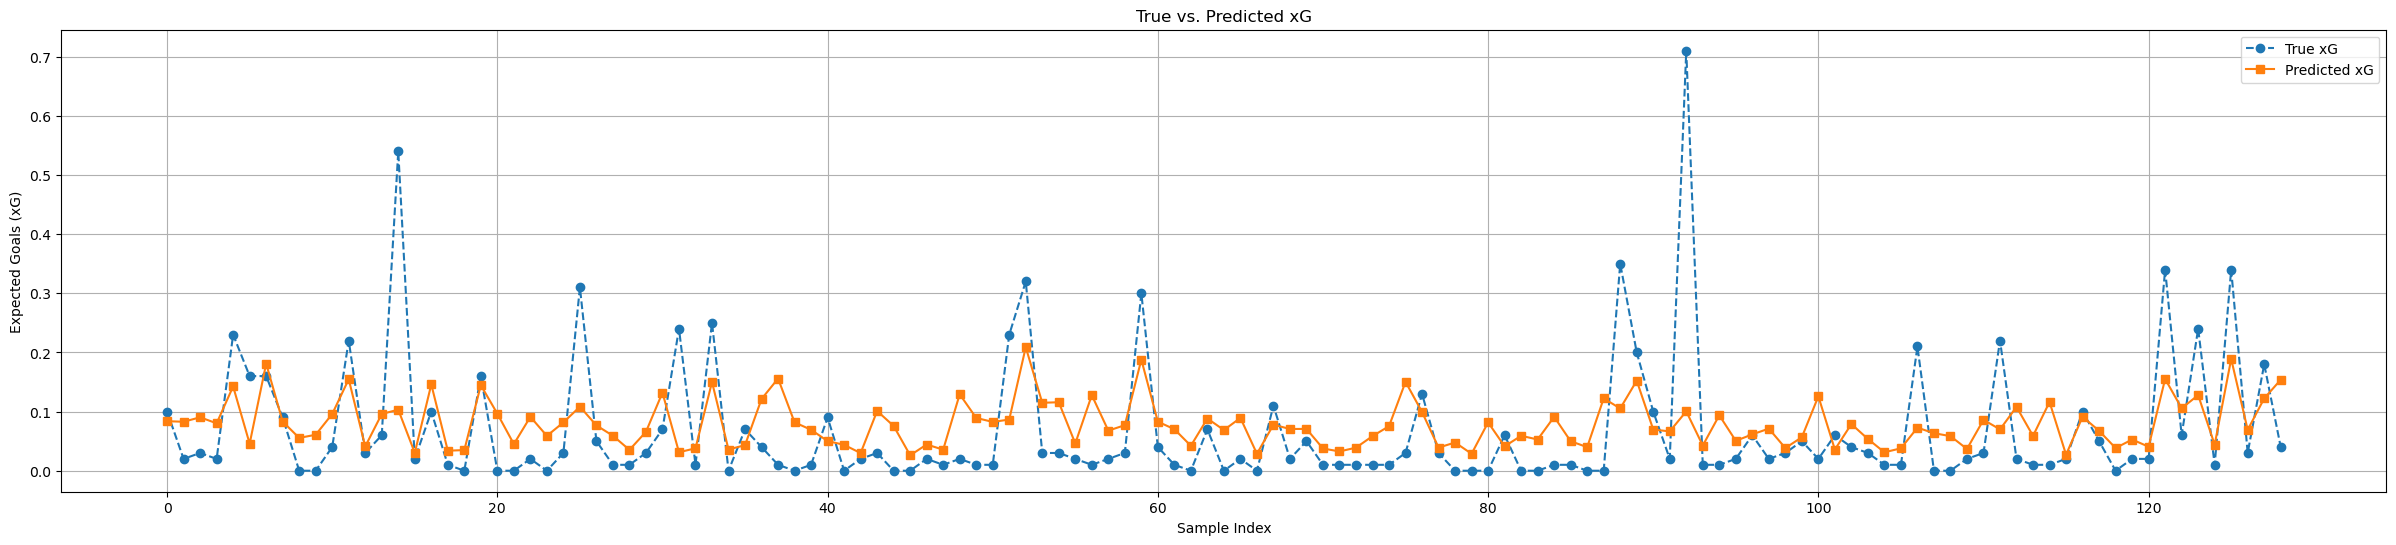

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(30, 6))
plt.plot(xa_tar.values, label="True xG", marker='o', linestyle='dashed')  # Convert DataFrame to array
plt.plot(xa_pred, label="Predicted xG", marker='s', linestyle='solid')

# Labels and Title
plt.xlabel("Sample Index")
plt.ylabel("Expected Goals (xG)")
plt.title("True vs. Predicted xG")
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:

xa_tar['xa_pred'] = xa_pred
# xa_tar = xa_tar.drop('expected_assists', axis=1)
# comb_data = comb_data.join(xa_tar, rsuffix='x')
# comb_data

def add_preds(row):
    if row.name in list(xa_tar.index):
        # print(row.name, xa_tar.loc[row.name, 'xa_pred'])
        row['xa_pred'] = xa_tar.loc[row.name, 'xa_pred']
    else:
        row['xa_pred'] = 0
    return row
data_tar_preds = data_tar_preds.apply(add_preds, axis=1)
data_tar_preds['xa_pred']

## Clean Sheets


In [ ]:
cs_data= data[(data['position'] != 'FWD')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'clean_sheets', 'clean_sheets_3', 'clean_sheets_5',
                                                                         'expected_goals_conceded_3', 'expected_goals_conceded_5', 'ict_index_3',  'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5',
                                                                         'threat_3', 'threat_5', 'whh', 'whd', 'wha']]

cs_data_tar = data_tar_[ (data_tar_['position'] != 'FWD')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'clean_sheets', 'clean_sheets_3', 'clean_sheets_5',
                                                                         'expected_goals_conceded_3', 'expected_goals_conceded_5', 'ict_index_3',  'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5',
                                                                         'threat_3', 'threat_5', 'whh', 'whd', 'wha']]

cs_data = cs_data.dropna()

In [ ]:
cs = cs_data[['clean_sheets']]
feats = cs_data.drop('clean_sheets', axis=1)

cs_tar = cs_data_tar[['clean_sheets']].copy()
feats_tar = cs_data_tar.drop('clean_sheets', axis=1)

In [ ]:
feats.isnull().sum()

In [ ]:
cs_hy_params = {'bootstrap': False, 'min_samples_split': 2, 'n_estimators': 100}
cs_pred = Random_Forest_Classifier(feats, feats_tar, column_or_1d(cs), cs_hy_params)
cs_tar['cs_pred'] = cs_pred
# cs_tar = cs_tar.drop('clean_sheets', axis=1)
# comb_data = comb_data.join(cs_tar, rsuffix='x')
# comb_data

def add_preds(row):
    if row.name in list(cs_tar.index):
        # print(row.name, cs_tar.loc[row.name, 'cs_pred'])
        row['cs_pred'] = cs_tar.loc[row.name, 'cs_pred']
    else:
        row['cs_pred'] = 0
    return row
data_tar_preds = data_tar_preds.apply(add_preds, axis=1)
data_tar_preds['cs_pred']

## Yellow Cards


In [ ]:
#
yc_data= data[ (data['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'ict_index_3',
                                                                         'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5',
                                                                         'yellow_cards', 'yellow_cards_3', 'yellow_cards_5', 'whh', 'whd', 'wha']]

yc_data_tar = data_tar_[ (data_tar_['position'] != 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'ict_index_3',
                                                                         'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5',
                                                                         'yellow_cards', 'yellow_cards_3', 'yellow_cards_5', 'whh', 'whd', 'wha']]


yc_data = yc_data.dropna()

In [ ]:
yc = yc_data[['yellow_cards']]
feats = yc_data.drop('yellow_cards', axis=1)

yc_tar = yc_data_tar[['yellow_cards']].copy()
feats_tar = yc_data_tar.drop('yellow_cards', axis=1)

In [ ]:
params =  {'bootstrap': False, 'min_samples_split': 10, 'n_estimators': 300}
yc_pred = Random_Forest_Classifier(feats, feats_tar, column_or_1d(yc), params)
yc_tar['yc_pred'] = yc_pred
# yc_tar = yc_tar.drop('yellow_cards', axis=1)
# comb_data = comb_data.merge(yc_tar, left_index=True, right_index=True, how='inner')
# comb_data

def add_preds(row):
    if row.name in list(yc_tar.index):
        # print(row.name, yc_tar.loc[row.name, 'yc_pred'])
        row['yc_pred'] = yc_tar.loc[row.name, 'yc_pred']
    else:
        row['yc_pred'] = 0
    return row
data_tar_preds = data_tar_preds.apply(add_preds, axis=1)
data_tar_preds['yc_pred']

## Saves


In [ ]:
sv_data= data[ (data['position'] == 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'ict_index_3',
                                                                         'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5',
                                                                         'clean_sheets_3', 'clean_sheets_5', 'expected_goals_conceded_3', 'expected_goals_conceded_5','saves',
                                                                          'saves_3', 'saves_5', 'whh', 'whd', 'wha']]

sv_data_tar = data_tar_[(data_tar_['position'] == 'GK')][['position', 'minutes_3', 'minutes_5', 'team_h_difficulty', 'team_a_difficulty', 'was_home', 'ict_index_3',
                                                                         'ict_index_5', 'influence_3', 'influence_5', 'creativity_3', 'creativity_5', 'threat_3', 'threat_5',
                                                                         'clean_sheets_3', 'clean_sheets_5', 'expected_goals_conceded_3', 'expected_goals_conceded_5','saves',
                                                                          'saves_3', 'saves_5', 'whh', 'whd', 'wha']]

sv_data = sv_data.dropna()

In [ ]:
sv = sv_data[['saves']]
feats = sv_data.drop(['saves', 'position'], axis=1)

sv_tar = sv_data_tar[['saves']].copy()
feats_tar = sv_data_tar.drop(['saves', 'position'], axis=1)

In [ ]:
sv_pred = Linear_regression(feats, feats_tar, sv)
sv_tar['sv_pred'] = sv_pred
# sv_tar = sv_tar.drop('saves', axis=1)
# comb_data = comb_data.join(sv_tar, rsuffix='x')
# comb_data

def add_preds(row):
    if row.name in list(sv_tar.index):
        # print(row.name, sv_tar.loc[row.name, 'sv_pred'])
        row['sv_pred'] = sv_tar.loc[row.name, 'sv_pred']
    else:
        row['sv_pred'] = 0
    return row
data_tar_preds = data_tar_preds.apply(add_preds, axis=1)
data_tar_preds['sv_pred']

## Total Points


In [ ]:
# For playing up to 60 minutes	1
# For playing 60 minutes or more (excluding stoppage time)	2
# For each goal scored by a goalkeeper	10
# For each goal scored by a defender	6
# For each goal scored by a midfielder	5
# For each goal scored by a forward	4
# For each goal assist	3
# For a clean sheet by a goalkeeper or defender	4
# For a clean sheet by a midfielder	1
# For every 3 shot saves by a goalkeeper	1
# For each penalty save	5
# For each penalty miss	-2
# Bonus points for the best players in a match	1-3
# For every 2 goals conceded by a goalkeeper or defender	-1
# For each yellow card	-1
# For each red card	-3
# For each own goal	-2

## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [ ]:
def calc_total_pts(row):
    if(row.position == 'GK'):
                ## ---> >60  = 2
        ## ---> cs*4
        ## ---> ((sv)/3)*1
        ## ---> gc
        ## ---> yc*-1
        row['xPts'] = 2 + row['cs_pred']*4 + ((row['sv_pred'])/3)*1 + row['yc_pred']*(-1)

    elif(row.position == 'DEF'):
        ## ---> >60  = 2
        ## ---> xg*6
        ## ---> xa*3
        ## ---> cs*4
        ## ---> gc
        ## ---> yc*-1
        row['xPts'] = 2 + row['xg_pred']*6 + row['xa_pred']*3 + row['cs_pred']*4 + row['yc_pred']*(-1)
    elif(row.position == 'MID'):
        ## MID
        ## ---> >60  = +2
        ## ---> xg*5
        ## ---> xa*3
        ## ---> cs*1
        ## ---> yc*-1

        row['xPts'] = 2 + row['xg_pred']*5 + row['xa_pred']*3 + row['cs_pred']*1 + row['yc_pred']*(-1)

    elif(row.position == 'FWD'):
        ## ---> >60  = 2
        ## ---> xg*4
        ## ---> xa*3
        ## ---> yc*-1

        row['xPts'] = 2 + row['xg_pred']*4 + row['xa_pred']*3 + row['yc_pred']*(-1)

    return row

data_tar_preds = data_tar_preds.apply(calc_total_pts, axis=1)
data_tar_preds

## Player Points


In [ ]:
data_tar_preds[['element', 'position', 'xPts']]

In [ ]:
data_tar_preds.to_csv('./predicted.csv', index=False)

In [ ]:
import pandas as pd

pd.read_csv('./predicted.csv')['player_team']